In [1]:
import pandas as pd

df = pd.DataFrame({
    "Sample_ID": [1, 2, 3, 4, 5],
    "Actual": [100, 120, 140, 160, 180],
    "Predicted": [95, 125, 130, 165, 170]
})

print(df)

   Sample_ID  Actual  Predicted
0          1     100         95
1          2     120        125
2          3     140        130
3          4     160        165
4          5     180        170


In [2]:
import matplotlib.pyplot as plt

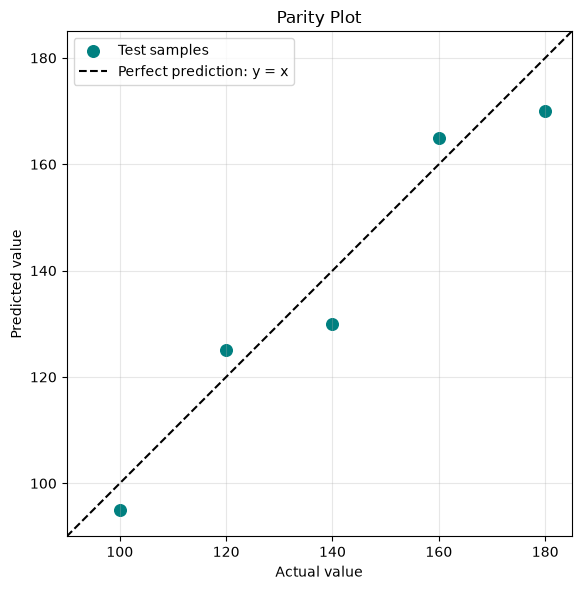

In [3]:
# Set common limits for both axes.
low = min(df["Actual"].min(), df["Predicted"].min()) - 5
high = max(df["Actual"].max(), df["Predicted"].max()) + 5

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(df["Actual"], df["Predicted"],
           color="teal", s=70, label="Test samples")

ax.plot([low, high], [low, high],
        "k--", label="Perfect prediction: y = x")

ax.set(
    xlabel="Actual value",
    ylabel="Predicted value",
    title="Parity Plot",
    xlim=(low, high),
    ylim=(low, high)
)
ax.set_aspect("equal", adjustable="box")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# Residual = actual value − predicted value
df["Residual"] = df["Actual"] - df["Predicted"]

print(df)

   Sample_ID  Actual  Predicted  Residual
0          1     100         95         5
1          2     120        125        -5
2          3     140        130        10
3          4     160        165        -5
4          5     180        170        10


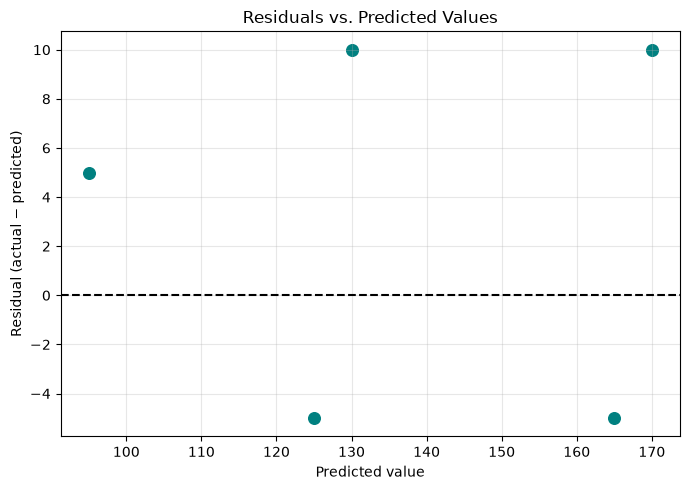

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    df["Predicted"],
    df["Residual"],
    color="teal",
    s=70
)

# Zero residual means an exact prediction.
ax.axhline(y=0, color="black", linestyle="--")

ax.set(
    xlabel="Predicted value",
    ylabel="Residual (actual − predicted)",
    title="Residuals vs. Predicted Values"
)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
import numpy as np

mae = np.mean(np.abs(df["Residual"]))
rmse = np.sqrt(np.mean(df["Residual"] ** 2))

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE:  7.00
RMSE: 7.42


In [7]:
diagnosis = f"""
The model has an MAE of {mae:.2f} and an RMSE of {rmse:.2f}.

Three samples are underpredicted and two are overpredicted.
The largest absolute error is {df["Residual"].abs().max():.2f} units.

Only five illustrative samples are available, so we cannot
reliably identify curvature or changing error variability.
A larger test set is needed to assess these patterns.
"""

print(diagnosis)


The model has an MAE of 7.00 and an RMSE of 7.42.

Three samples are underpredicted and two are overpredicted.
The largest absolute error is 10.00 units.

Only five illustrative samples are available, so we cannot
reliably identify curvature or changing error variability.
A larger test set is needed to assess these patterns.



In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(27)

# A synthetic materials descriptor.
feature_1 = rng.normal(size=120)

# A second descriptor strongly correlated with the first.
feature_2 = feature_1 + rng.normal(scale=0.05, size=120)

# A synthetic measured property, including measurement noise.
target = 100 + 20 * feature_1 + rng.normal(scale=5, size=120)

data = pd.DataFrame({
    "Feature_1": feature_1,
    "Feature_2": feature_2,
    "Target": target
})

print(data.head())
print("\nFeature correlation:")
print(data[["Feature_1", "Feature_2"]].corr())

   Feature_1  Feature_2      Target
0   1.254448   1.228245  126.013340
1   0.776902   0.664428  116.206744
2   0.964881   0.948964  126.044116
3  -1.082178  -1.128165   81.098037
4   0.867017   0.913464  117.133035

Feature correlation:
           Feature_1  Feature_2
Feature_1   1.000000   0.998685
Feature_2   0.998685   1.000000


In [2]:
from sklearn.model_selection import train_test_split

# Inputs: the two correlated descriptors.
X = data[["Feature_1", "Feature_2"]]

# Output: the property we want to predict.
y = data["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=27
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 90
Test samples: 30
